# 06 - Maternal ECG cancellation

Goal: estimate the maternal ECG from `S4` using the detected maternal QRS positions, then subtract it to obtain `S5`.

## Why this step is needed

The abdominal ECG is a mixture of maternal ECG, fetal ECG, and noise. The maternal ECG is usually much stronger than the fetal ECG, so fetal QRS detection is difficult before maternal cancellation.

In the previous notebook we detected the maternal QRS positions. Here we use those positions to estimate the maternal ECG waveform and subtract it from `S4`.

In [9]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import data_io
import preprocessing
import qrs_detection
import mecg_cancellation
import plotting

# Reload local modules so Jupyter picks up code changes during development.
importlib.reload(data_io)
importlib.reload(preprocessing)
importlib.reload(qrs_detection)
importlib.reload(mecg_cancellation)
importlib.reload(plotting)

from data_io import load_record
from preprocessing import remove_baseline_wander, remove_powerline_interference, upsample_signals
from qrs_detection import detect_maternal_qrs
from mecg_cancellation import cancel_maternal_ecg, qrs_window_rms
from plotting import plot_mecg_cancellation_comparison, plot_mecg_cancellation_detail


## Load the record and rebuild S4

`S4` is rebuilt here so this notebook can run independently.

In [10]:
record = load_record('a14')
S1 = record.signals

baseline_result = remove_baseline_wander(
    S1,
    fs=record.fs,
    cutoff_hz=3.0,
    numtaps=1001,
)
S2 = baseline_result.filtered_signals

powerline_result = remove_powerline_interference(
    S2,
    fs=record.fs,
    frequencies_hz=(50.0, 100.0, 150.0),
)
S3 = powerline_result.cleaned_signals

upsampling_result = upsample_signals(
    S3,
    fs=record.fs,
    target_fs=2000.0,
)
S4 = upsampling_result.upsampled_signals
fs_s4 = upsampling_result.target_fs
duration_s = S4.shape[0] / fs_s4

print(f'Record: {record.name}')
print(f'S4 shape: {S4.shape}')
print(f'S4 sampling frequency: {fs_s4:.0f} Hz')
print(f'S4 duration: {duration_s:.2f} s')


Record: a14
S4 shape: (120000, 4)
S4 sampling frequency: 2000 Hz
S4 duration: 60.00 s


## Detect maternal QRS positions

The maternal ECG canceller needs the maternal QRS positions. We detect them again here so the notebook is self-contained.

In [11]:
mqrs_result = detect_maternal_qrs(
    S4,
    fs=fs_s4,
    max_heart_rate_bpm=140.0,
)
mqrs_samples = mqrs_result.mqrs_samples
mqrs_times = mqrs_samples / fs_s4

print(f'Detected MQRS: {len(mqrs_samples)}')
print(f'First five MQRS times: {np.round(mqrs_times[:5], 4)} s')


Detected MQRS: 102
First five MQRS times: [0.2955 0.922  1.5505 2.187  2.8175] s


## Apply maternal ECG cancellation

For each maternal beat, the algorithm uses the 10 preceding maternal beats to build a local maternal ECG estimate. The estimate is split into P-wave, QRS-complex, and T-wave zones. Each zone is scaled separately, then the full estimated maternal ECG is subtracted from `S4`.

In [12]:
mecg_result = cancel_maternal_ecg(
    S4,
    mqrs_samples=mqrs_samples,
    fs=fs_s4,
    preceding_beats=10,
    before_s=0.25,
    after_s=0.45,
    qrs_half_width_s=0.05,
)
S5 = mecg_result.cancelled_signals
estimated_mecg = mecg_result.estimated_mecg

print(f'S5 shape: {S5.shape}')
print(f'MQRS available: {len(mqrs_samples)}')
print(f'MQRS cancelled: {len(mecg_result.cancelled_mqrs_samples)}')
print(f'First cancelled MQRS time: {mecg_result.cancelled_mqrs_samples[0] / fs_s4:.3f} s')


S5 shape: (120000, 4)
MQRS available: 102
MQRS cancelled: 91
First cancelled MQRS time: 6.583 s


## Quantify the reduction around maternal QRS positions

As a simple check, we compare the RMS amplitude around the maternal QRS positions before and after cancellation. A lower RMS after cancellation means that the large maternal QRS peaks were reduced.

In [13]:
before_rms = qrs_window_rms(
    S4,
    mecg_result.cancelled_mqrs_samples,
    fs=fs_s4,
    half_width_s=0.05,
)
after_rms = qrs_window_rms(
    S5,
    mecg_result.cancelled_mqrs_samples,
    fs=fs_s4,
    half_width_s=0.05,
)
reduction_pct = (1.0 - after_rms / before_rms) * 100.0

summary = pd.DataFrame({
    'channel': record.channels,
    'rms_before_s4': before_rms,
    'rms_after_s5': after_rms,
    'reduction_percent': reduction_pct,
})
results_dir = PROJECT_ROOT / 'results' / 'notebook06'
results_dir.mkdir(parents=True, exist_ok=True)
summary_path = results_dir / 'a14_mecg_cancellation_summary.csv'
summary.to_csv(summary_path, index=False)
summary


,channel,rms_before_s4,rms_after_s5,reduction_percent
0,AECG1,43.789793,8.510600,80.564877
1,AECG2,33.662435,7.011410,79.171411
2,AECG3,11.502514,7.883965,31.458767
3,AECG4,33.914746,6.199012,81.721780


## Before/after comparison

These plots compare `S4` and `S5`. The window starts after the first 10 maternal beats, because those first beats are used as history for the first maternal ECG estimate.

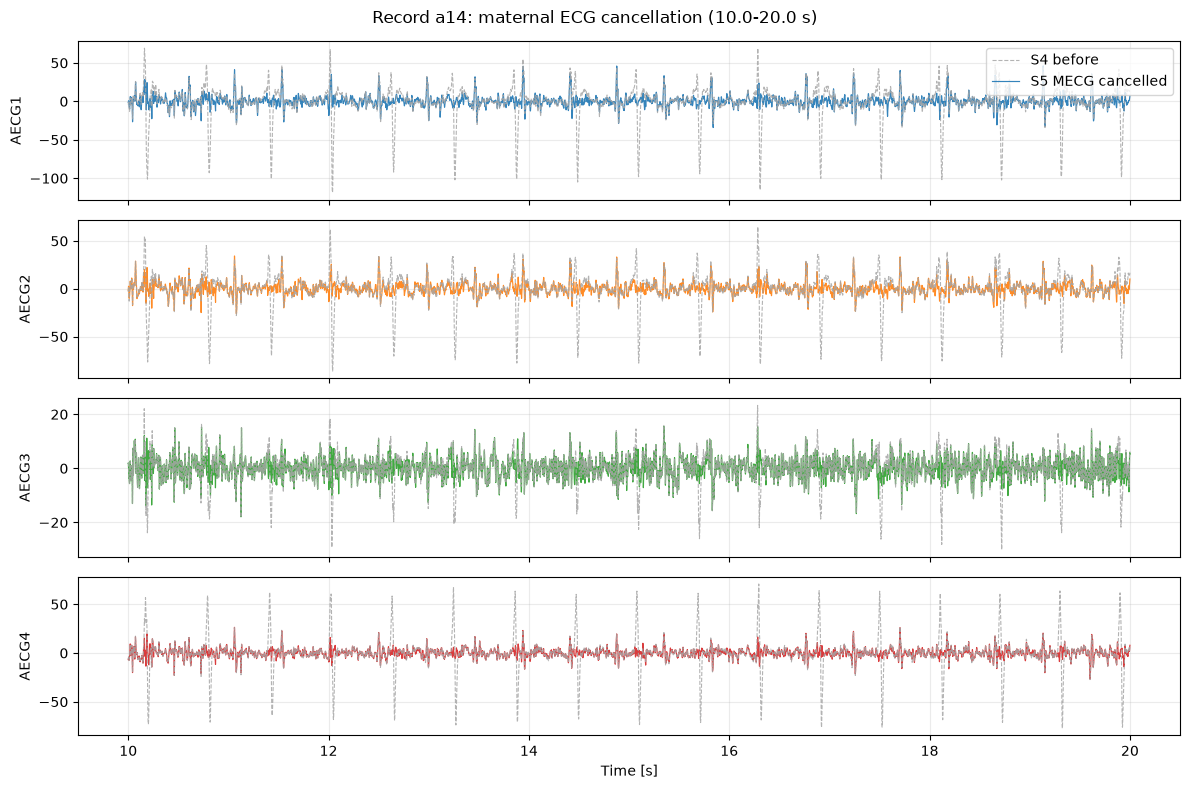

In [14]:
fig, axes = plot_mecg_cancellation_comparison(
    record,
    S4,
    S5,
    fs=fs_s4,
    seconds=(10, 20),
    save_path=PROJECT_ROOT / 'figures' / 'notebook06' / 'a14_s4_s5_mecg_cancellation_10_20s.png',
)
plt.show()


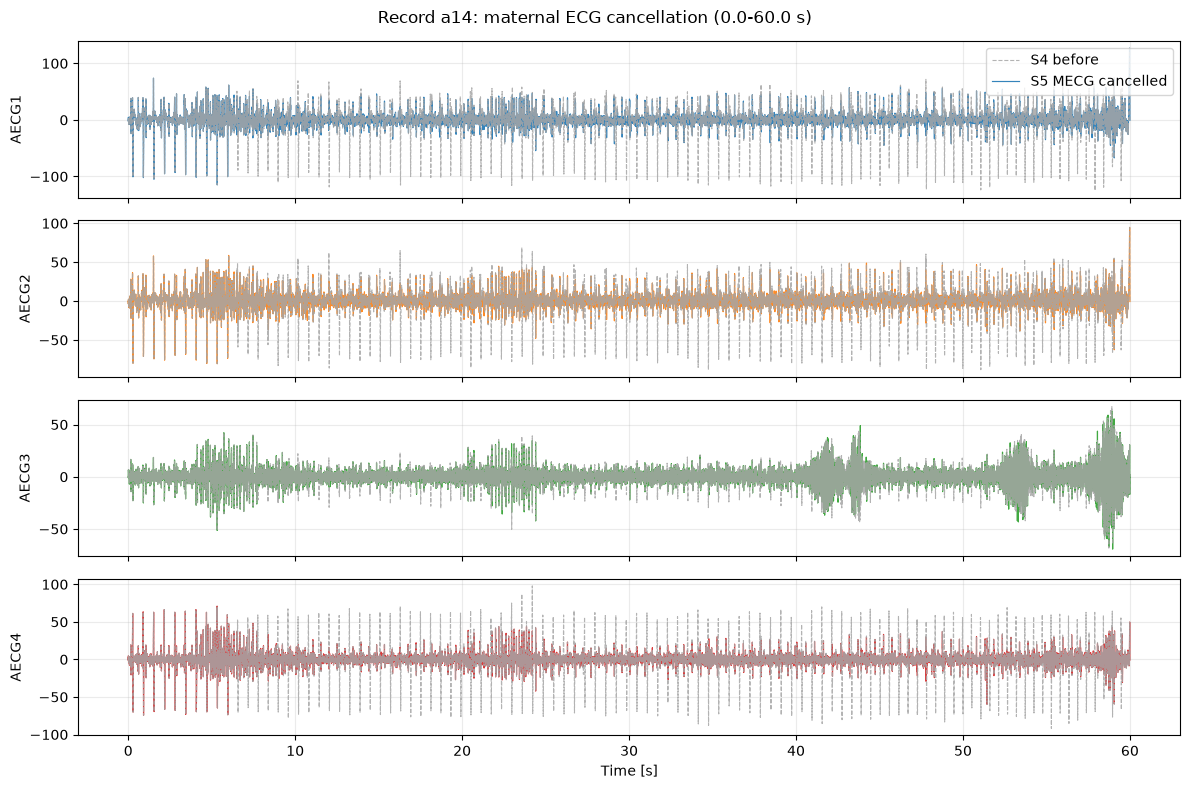

In [15]:
fig, axes = plot_mecg_cancellation_comparison(
    record,
    S4,
    S5,
    fs=fs_s4,
    seconds=(0, duration_s),
    save_path=PROJECT_ROOT / 'figures' / 'notebook06' / 'a14_s4_s5_mecg_cancellation_full.png',
)
plt.show()


## Detail view

This plot shows one channel in detail: original `S4`, estimated maternal ECG, and residual `S5`. It helps verify that the subtracted signal lines up with the maternal QRS positions.

Detail channel: AECG4


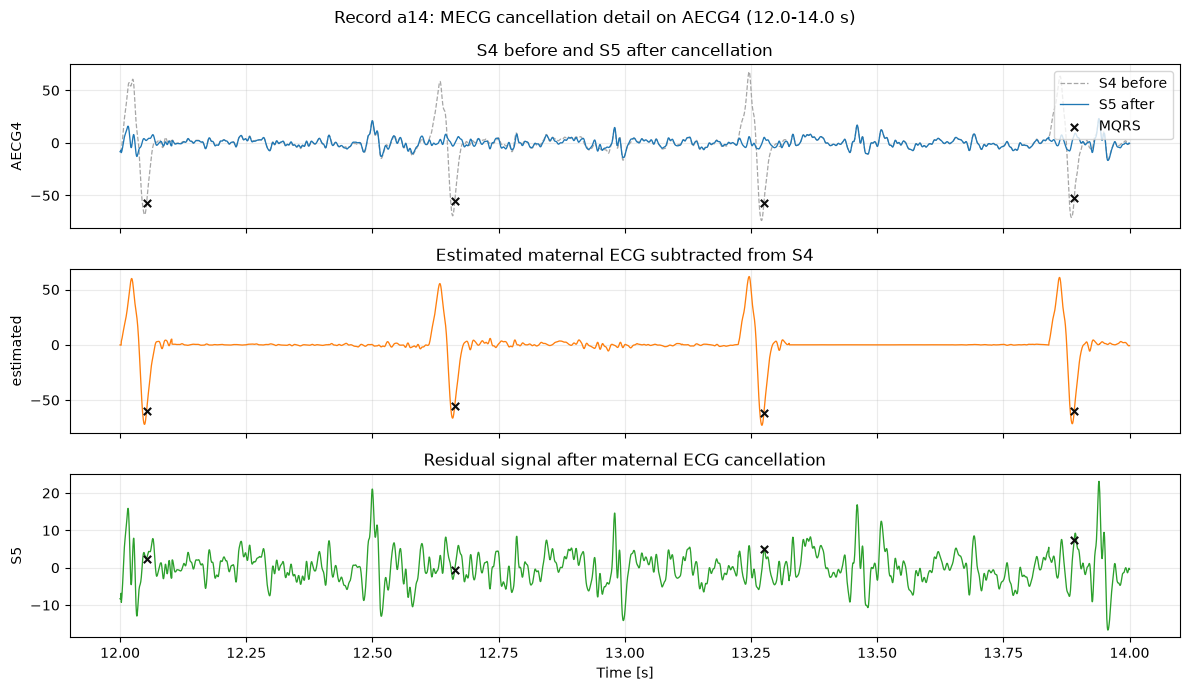

In [16]:
detail_channel = int(np.nanargmax(reduction_pct))
detail_channel_name = record.channels[detail_channel]
print(f'Detail channel: {detail_channel_name}')

fig, axes = plot_mecg_cancellation_detail(
    record,
    S4,
    estimated_mecg,
    S5,
    fs=fs_s4,
    mqrs_samples=mecg_result.cancelled_mqrs_samples,
    channel=detail_channel,
    seconds=(12, 14),
    save_path=PROJECT_ROOT / 'figures' / 'notebook06' / 'a14_mecg_cancellation_detail_strongest_channel_12_14s.png',
)
plt.show()


## Output of this step

`S5` is the abdominal ECG after maternal ECG cancellation. It still contains fetal ECG, residual noise, and possible remaining maternal components, but the strongest maternal QRS peaks are reduced. The next step is fetal QRS detection on `S5`.